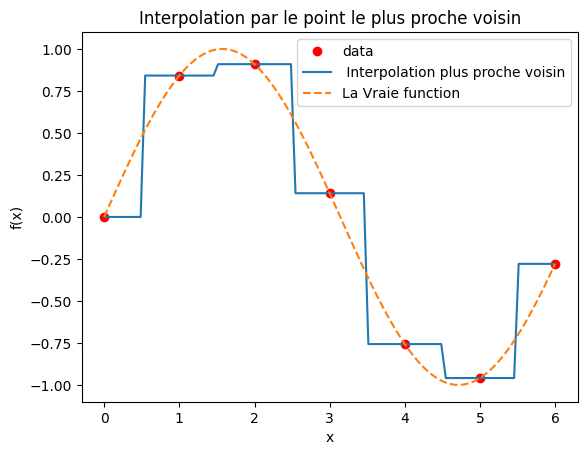

In [4]:
import numpy as np
import matplotlib.pyplot as plt
# -*- coding: utf-8 -*-

""" By Fabrice PAKA"""

def f_plus_proche_voisin(x, xdata, fdata):
    """Retourne l'interpolation par plus proche voisin d'une fonction au point x.
       xdata et ydata sont les points de données utilisés pour l'interpolation.
       On suppose que xdata est trié par ordre croissant"""
    ind = np.searchsorted(xdata, x) # Search the right interval for point x
    if (ind == 0):
        return fdata[0]
    if (ind == len(xdata)):
        return fdata[-1]
    x0,f0 = xdata[ind-1],fdata[ind-1]
    x1,f1 = xdata[ind],fdata[ind]
    if (abs(x-x0) < abs(x-x1)):
        return f0
    else:
        return f1
if __name__=='__main__':
    # Calcul des valeurs de f(x) en utilisant l'interpolation lineaire
        # Les données d'interpolation.
        xdat = np.array([0, 1, 2, 3, 4, 5, 6])
        fdat = np.sin(xdat)
        # Référence pour la fonction réelle
        xref = np.linspace(0,6,100)
        fref = np.sin(xref)    
        xcalc = np.linspace(0,6,100)
        fcalc = [f_plus_proche_voisin(xin,xdat,fdat) for xin in xcalc]

        plt.title("Interpolation par le point le plus proche voisin")
        plt.xlabel("x")
        plt.ylabel("f(x)")
        plt.plot(xdat,fdat,'or',label='data')
        plt.plot(xcalc,fcalc,label=' Interpolation plus proche voisin')
        plt.plot(xref,fref,'--',label='La Vraie function')
        plt.legend()
        plt.savefig("interpolation_plus_proche_voisin.png")
        plt.show()    

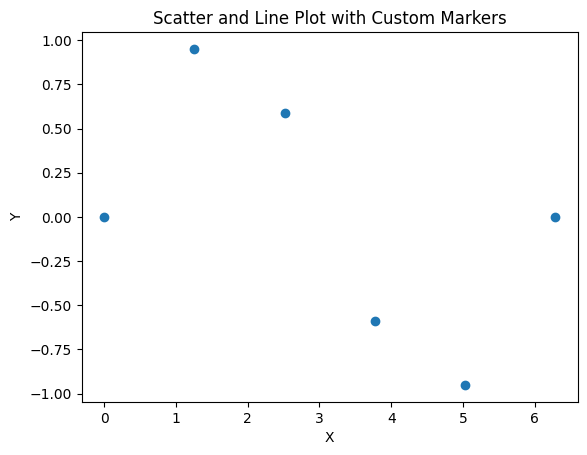

### Interpolation lineaire

This script is not meant to be run directly.


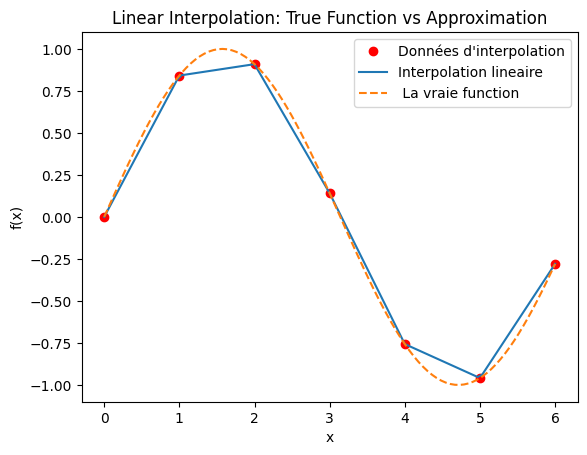

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# -*- coding: utf-8 -*-
""" By Fabrice PAKA"""
def interpolation_lineair(x,x0,f0,x1,f1):
    """Retourne la valeur d'une fonction a un point x
    à travers interpolation lineaire entre les points (x0,y0) et (x1,y1)."""
    return f0 + (f1 - f0) * (x-x0) / (x1-x0)


def f_interpoler_lineairement(x, xdata, fdata):
    """Retourne l'interpolation lineaire d'une fonction en un point x.
    xdata et ydata sont les  points utilisé pour faire l'interpolation.
    xdata est supposé ètre iordonné de façon croissante."""
    ind = np.searchsorted(xdata, x) # Cherche le bon intervalle pour x
    if (ind == 0):
        #if ((xdata[0] - x) > 1e-12): 
        if (xdata[0] > x):
            print(f"x = { x} est hors de la l'intervalle d'interpolation [{xdata[0]}, {xdata[-1]} ]")
        ind = ind + 1
    if (ind == len(xdata)):
        if (x > xdata[-1]):
        #if ((x - xdata[-1]) > 1e-12):
            print(f"x = { x} est hors de la l'intervalle d'interpolation [{xdata[0]}, {xdata[-1]} ]")
        ind = ind - 1
    x0,f0 = xdata[ind-1],fdata[ind-1]
    x1,f1 = xdata[ind],fdata[ind]
    return interpolation_lineair(x,x0,f0,x1,f1)

if __name__ == "__main__":  
    # Calcul des valeurs de f(x) en utilisant l'interpolation lineaire
    # Les données d'interpolation.
    xdat = np.array([0, 1, 2, 3, 4, 5, 6])
    fdat = np.sin(xdat)
    # Référence pour la fonction réelle
    xref = np.linspace(0,6,100)
    fref = np.sin(xref)

    # Interpolation lineaire
    xcalc = np.linspace(0,6,100)
    fcalc = [f_interpoler_lineairement(xin, xdat, fdat) for xin in xcalc]

    # Affichage des résultats
    plt.title("Linear Interpolation: True Function vs Approximation")
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.plot(xdat,fdat,'or',label="Données d'interpolation")
    plt.plot(xcalc,fcalc,label='Interpolation lineaire')
    plt.plot(xref,fref,'--',label=' La vraie function')
    plt.legend()
    plt.savefig('interpolation_plot.png')
    plt.show()

### Interpolation Polynomial( de Lagrange)

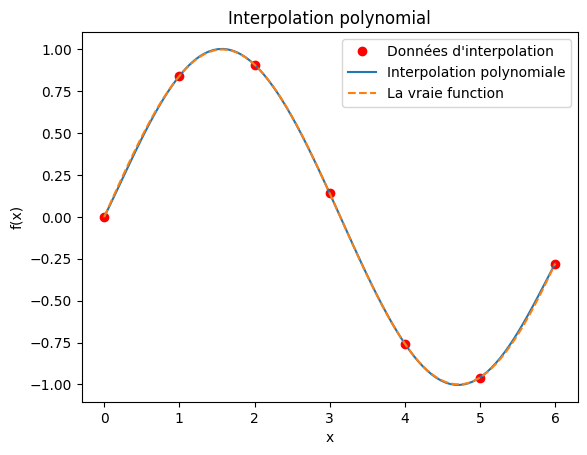

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# -*- coding: utf-8 -*-

""" By Fabrice PAKA, le code fonctionne !!!"""

def Lkj(x,j,xdata):
    """Fonction de base de lagrange."""
    ret = 1.
    #for k in range(0, len(xdata)):
    #    if (k != j):
    #        ret *= (x - xdata[k]) / (xdata[j] - xdata[k])
    ret *= np.prod([(x - xdata[k]) / (xdata[j] - xdata[k]) for k in range(len(xdata)) if k != j])
    return ret

def f_interpolation_polynomial(x, xdata, fdata):
    """Retourne l'interpolation polynomiale d'une fonction au point x.
xdata et ydata sont les points de données utilisés pour l'interpolation."""
    ret = 0.
    n = len(xdata) - 1
    for j in range(0, n+1):
        ret += fdata[j] * Lkj(x,j,xdata)
    return ret
if __name__ == "__main__": 
    # Calcul des valeurs de f(x) en utilisant l'interpolation lineaire
    # Les données d'interpolation.
    xdat = np.array([0, 1, 2, 3, 4, 5, 6])
    fdat = np.sin(xdat)
    # Référence pour la fonction réelle
    xref = np.linspace(0,6,100)
    fref = np.sin(xref)
    # Interpolation polynomiale
    xpoly = np.linspace(0,6,100)
    fpoly = [f_interpolation_polynomial(xin,xdat,fdat) for xin in xpoly]
    
    # Affichage des résultats
    plt.title("Interpolation polynomiale")
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.plot(xdat,fdat,'or',label="Données d'interpolation")
    plt.plot(xpoly,fpoly,label='Interpolation polynomiale')
    plt.plot(xref,fref,'--',label='La vraie function')
    plt.legend()
    plt.savefig("interpolation_polynomial.png")
    plt.show()



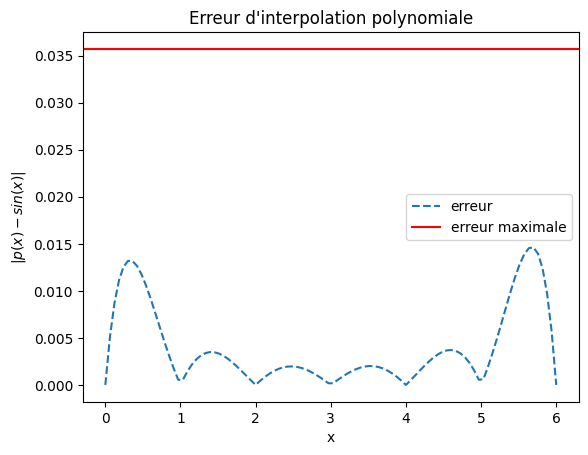

In [12]:
plt.title("Erreur d'interpolation polynomiale")
plt.xlabel("x")
plt.ylabel("${|p(x) - sin(x)|}$")
plt.plot(xref,abs(fref-fpoly),'--',label='erreur')
n = len(xdat) - 1
plt.axhline(y = (xdat[1]-xdat[0])**n/4./(n+1.), color = 'r', linestyle = '-',label='erreur maximale')
plt.legend()
plt.savefig("interpolation_error.png")
plt.show()